In [1]:
import pandas as pd
import xarray as xr
import cftime
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
df_grids =pd.read_csv('../grid_data/grids.csv',index_col=0)

In [3]:
shp = gpd.read_file('../map/germany.shp')  # 替换为shp文件路径

In [4]:
df1=pd.read_csv('../grid_data/ssp1/rlds_2030.csv',index_col=0)
df2=pd.read_csv('../grid_data/ssp2_n/rlds_2030.csv',index_col=0)
df3=pd.read_csv('../grid_data/ssp5_n/rlds_2030.csv',index_col=0)

In [5]:
annual_ssp1 = df1.groupby('sites')[['rlds']].mean().reset_index()
annual_ssp1 =pd.merge(annual_ssp1,df_grids,left_on='sites',right_on='index')
annual_ssp2 = df2.groupby('sites')[['rlds']].mean().reset_index()
annual_ssp2 =pd.merge(annual_ssp2,df_grids,left_on='sites',right_on='index')
annual_ssp5 = df3.groupby('sites')[['rlds']].mean().reset_index()
annual_ssp5 =pd.merge(annual_ssp5,df_grids,left_on='sites',right_on='index')

In [6]:
annual_ssp1.set_index(['lat', 'lon'], inplace=True)
annual_ssp1 =annual_ssp1.to_xarray()
annual_ssp2.set_index(['lat', 'lon'], inplace=True)
annual_ssp2 =annual_ssp2.to_xarray()
annual_ssp5.set_index(['lat', 'lon'], inplace=True)
annual_ssp5 =annual_ssp5.to_xarray()

/tmp/ipykernel_4050108/3964582320.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


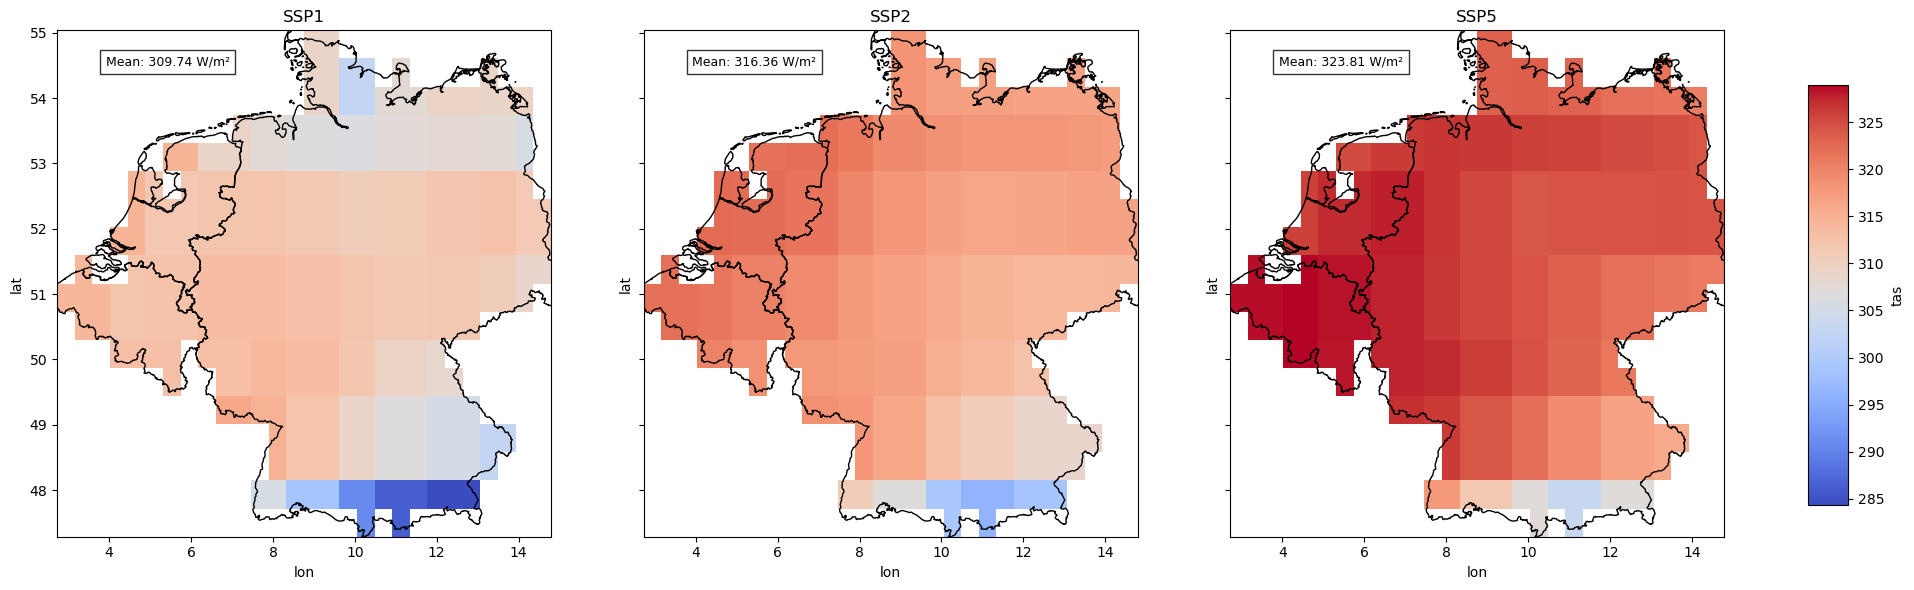

In [7]:
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import numpy as np

# 假设 annual_ssp1, annual_ssp2, annual_ssp3 是你的温度数据集
# 提取每个数据集的 t2m 数据
t2m_data_ssp1 = annual_ssp1['rlds']
t2m_data_ssp2 = annual_ssp2['rlds']
t2m_data_ssp3 = annual_ssp5['rlds']  # 新增的第三个数据集

# 计算不包含 NaN 的最小值和最大值（用于统一颜色范围）
vmin = np.nanmin([t2m_data_ssp1.values, t2m_data_ssp2.values, t2m_data_ssp3.values])
vmax = np.nanmax([t2m_data_ssp1.values, t2m_data_ssp2.values, t2m_data_ssp3.values])

# 加载德国shapefile数据（确保文件路径正确）
germany = gpd.read_file('../map/germany.shp')


# 创建画布和子图（1行3列）
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)

# 计算每个数据集的平均值
mean1 = t2m_data_ssp1.mean().values
mean2 = t2m_data_ssp2.mean().values
mean3 = t2m_data_ssp3.mean().values  # 第三个数据集的平均值

# 绘制 ssp1 温度数据
im1 = t2m_data_ssp1.plot(ax=axs[0], x='lon', y='lat', cmap='coolwarm', add_colorbar=False, vmin=vmin, vmax=vmax)
axs[0].set_title('SSP1')
germany.plot(ax=axs[0], edgecolor='black', facecolor='none')  # 绘制德国边界
axs[0].text(0.35, 0.95, f'Mean: {mean1:.2f} W/m²', transform=axs[0].transAxes, 
            bbox=dict(facecolor='white', alpha=0.8), fontsize=9, ha='right', va='top')

# 绘制 ssp2 温度数据
im2 = t2m_data_ssp2.plot(ax=axs[1], x='lon', y='lat', cmap='coolwarm', add_colorbar=False, vmin=vmin, vmax=vmax)
axs[1].set_title('SSP2')
germany.plot(ax=axs[1], edgecolor='black', facecolor='none')  # 绘制德国边界
axs[1].text(0.35, 0.95, f'Mean: {mean2:.2f} W/m²', transform=axs[1].transAxes, 
            bbox=dict(facecolor='white', alpha=0.8), fontsize=9, ha='right', va='top')

# 绘制 ssp3 温度数据（新增）
im3 = t2m_data_ssp3.plot(ax=axs[2], x='lon', y='lat', cmap='coolwarm', add_colorbar=False, vmin=vmin, vmax=vmax)
axs[2].set_title('SSP5')
germany.plot(ax=axs[2], edgecolor='black', facecolor='none')  # 绘制德国边界
axs[2].text(0.35, 0.95, f'Mean: {mean3:.2f} W/m²', transform=axs[2].transAxes, 
            bbox=dict(facecolor='white', alpha=0.8), fontsize=9, ha='right', va='top')

# 添加共享的颜色条
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # 调整位置和大小
cbar = fig.colorbar(im1, cax=cbar_ax)
cbar.set_label('tas')  # 更新颜色条标签为温度单位

# 调整布局，为颜色条留出空间
plt.tight_layout(rect=[0, 0, 0.9, 1])

# 显示图形
plt.show()

In [8]:
df1=pd.read_csv('../grid_data/ssp1/tas_2030.csv',index_col=0)
df2=pd.read_csv('../grid_data/ssp2_n/tas_2030.csv',index_col=0)
df3=pd.read_csv('../grid_data/ssp5_n/tas_2030.csv',index_col=0)

In [9]:
annual_ssp1 = df1.groupby('sites')[['tas']].mean().reset_index()
annual_ssp1 =pd.merge(annual_ssp1,df_grids,left_on='sites',right_on='index')
annual_ssp2 = df2.groupby('sites')[['tas']].mean().reset_index()
annual_ssp2 =pd.merge(annual_ssp2,df_grids,left_on='sites',right_on='index')
annual_ssp5 = df3.groupby('sites')[['tas']].mean().reset_index()
annual_ssp5 =pd.merge(annual_ssp5,df_grids,left_on='sites',right_on='index')

In [10]:
annual_ssp1.set_index(['lat', 'lon'], inplace=True)
annual_ssp1 =annual_ssp1.to_xarray()
annual_ssp2.set_index(['lat', 'lon'], inplace=True)
annual_ssp2 =annual_ssp2.to_xarray()
annual_ssp5.set_index(['lat', 'lon'], inplace=True)
annual_ssp5 =annual_ssp5.to_xarray()

/tmp/ipykernel_4050108/869138784.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


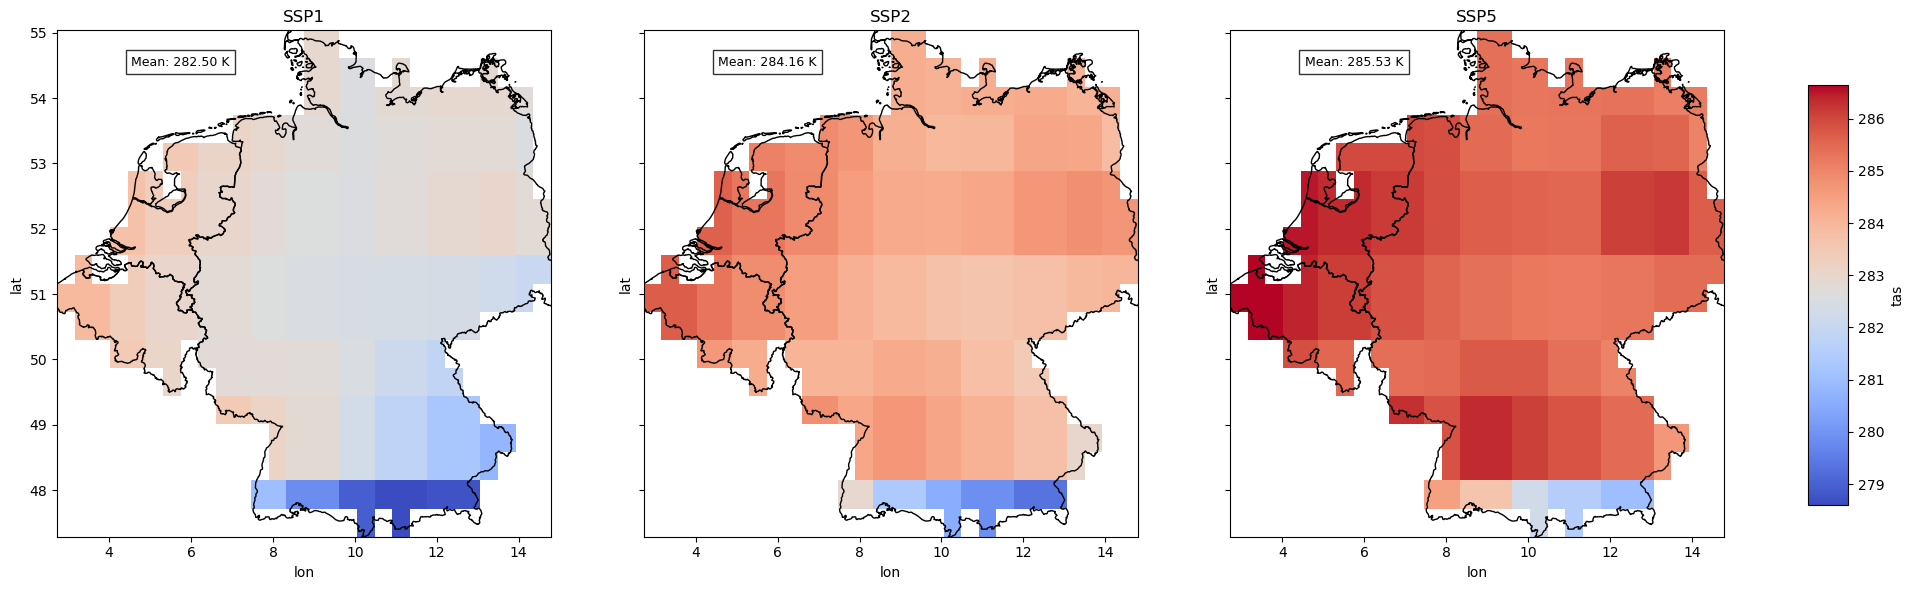

In [11]:
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import numpy as np

# 假设 annual_ssp1, annual_ssp2, annual_ssp3 是你的温度数据集
# 提取每个数据集的 t2m 数据
t2m_data_ssp1 = annual_ssp1['tas']
t2m_data_ssp2 = annual_ssp2['tas']
t2m_data_ssp3 = annual_ssp5['tas']  # 新增的第三个数据集

# 计算不包含 NaN 的最小值和最大值（用于统一颜色范围）
vmin = np.nanmin([t2m_data_ssp1.values, t2m_data_ssp2.values, t2m_data_ssp3.values])
vmax = np.nanmax([t2m_data_ssp1.values, t2m_data_ssp2.values, t2m_data_ssp3.values])

# 加载德国shapefile数据（确保文件路径正确）
germany = gpd.read_file('../map/germany.shp')


# 创建画布和子图（1行3列）
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)

# 计算每个数据集的平均值
mean1 = t2m_data_ssp1.mean().values
mean2 = t2m_data_ssp2.mean().values
mean3 = t2m_data_ssp3.mean().values  # 第三个数据集的平均值

# 绘制 ssp1 温度数据
im1 = t2m_data_ssp1.plot(ax=axs[0], x='lon', y='lat', cmap='coolwarm', add_colorbar=False, vmin=vmin, vmax=vmax)
axs[0].set_title('SSP1')
germany.plot(ax=axs[0], edgecolor='black', facecolor='none')  # 绘制德国边界
axs[0].text(0.35, 0.95, f'Mean: {mean1:.2f} K', transform=axs[0].transAxes, 
            bbox=dict(facecolor='white', alpha=0.8), fontsize=9, ha='right', va='top')

# 绘制 ssp2 温度数据
im2 = t2m_data_ssp2.plot(ax=axs[1], x='lon', y='lat', cmap='coolwarm', add_colorbar=False, vmin=vmin, vmax=vmax)
axs[1].set_title('SSP2')
germany.plot(ax=axs[1], edgecolor='black', facecolor='none')  # 绘制德国边界
axs[1].text(0.35, 0.95, f'Mean: {mean2:.2f} K', transform=axs[1].transAxes, 
            bbox=dict(facecolor='white', alpha=0.8), fontsize=9, ha='right', va='top')

# 绘制 ssp3 温度数据（新增）
im3 = t2m_data_ssp3.plot(ax=axs[2], x='lon', y='lat', cmap='coolwarm', add_colorbar=False, vmin=vmin, vmax=vmax)
axs[2].set_title('SSP5')
germany.plot(ax=axs[2], edgecolor='black', facecolor='none')  # 绘制德国边界
axs[2].text(0.35, 0.95, f'Mean: {mean3:.2f} K', transform=axs[2].transAxes, 
            bbox=dict(facecolor='white', alpha=0.8), fontsize=9, ha='right', va='top')

# 添加共享的颜色条
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # 调整位置和大小
cbar = fig.colorbar(im1, cax=cbar_ax)
cbar.set_label('tas')  # 更新颜色条标签为温度单位

# 调整布局，为颜色条留出空间
plt.tight_layout(rect=[0, 0, 0.9, 1])

# 显示图形
plt.show()